# Introduction to Bayesian Inference
## Modelling Glacier Melt from Air Temperature

**EARTHLAB 2026** — Wednesday Morning Practical (Francesco Muschitiello)

---

### What are we doing?

In this practical, we will build a **Bayesian statistical model** from scratch using nothing but NumPy and SciPy — no black-box libraries. We will work through two problems:

1. **A coin-flipping experiment** — the simplest possible setting to understand Bayes' theorem, and a case where the posterior can be written down *analytically* thanks to **conjugate priors**.
2. **A real glaciological dataset** — daily melt measured on a glacier in Spitsbergen, where we will see a classical (frequentist) regression produce a *physically impossible* result, and fix it by designing a Bayesian model whose prior encodes a physical law. Because this model has no analytical solution, we will write our own **Markov Chain Monte Carlo (MCMC)** sampler to explore the posterior.

### Why Bayesian methods for Earth science?

Earth and environmental datasets are often **small, noisy, and expensive to extend** — exactly the regime where frequentist methods struggle to fit stable models. Bayesian inference offers three things in return:

- **Full uncertainty quantification**: posterior *distributions* for every parameter, not point estimates.
- **Prior knowledge**: physical limits and domain expertise enter the model explicitly.
- **Robustness to small/noisy data**: priors stabilise the estimation when observations are scarce.

The community has noticed — the use of Bayesian methods in Earth and Environmental Science has grown exponentially:

<img src="assets/bayes_papers_growth.png" width="550">

*Number of publications applying Bayesian statistics in Earth and Environmental Science (data source: Scopus).*

### The dataset

`Glac_Melt.csv` — recorded daily on a glacier in Spitsbergen during the summer of 1999 (data courtesy of Prof. Gareth Rees):

| Column | Description | Units |
|--------|-------------|-------|
| `Day` | Day number, counting from 1 January | — |
| `AvTemp` | Average air temperature for the day | °C |
| `Melt` | Measured surface melt | mm |

Glaciological theory holds that melt is driven by short-wave solar radiation, sensible heat from warm air, and latent heat from condensation/evaporation at the ice surface — so we expect a strong (and slightly nonlinear) relationship between melt and air temperature. That is the relationship we will model today.

### What you will learn

1. How Bayes' theorem updates a **prior** belief into a **posterior** using a **likelihood**
2. What a **conjugate prior** is, and when you get the posterior *for free* (no sampling needed!)
3. Why most real-world models are *not* conjugate — and how **Metropolis–Hastings MCMC** solves this
4. How to encode physical knowledge in priors, and report **credible intervals** instead of point estimates

Let's get started!

---

## 1. Import Main Libraries

Everything today runs on the familiar scientific Python stack — a nice change of pace after two days of PyTorch!

In [1]:
import numpy as np              # numerical computations and array operations
import pandas as pd             # data manipulation with DataFrames
import matplotlib.pyplot as plt # plotting
import scipy.stats as stats     # statistical distributions

rng = np.random.default_rng(42) # a seeded random generator, for reproducibility

---

## 2. What is Bayesian Statistics?

**Bayesian statistics is a way of updating our beliefs based on new evidence.** You start with an initial belief (the *prior*), collect data, and revise that belief into an updated one (the *posterior*). In a sense, this mirrors the process of learning itself — and it forms a foundational framework for much of machine learning.

The Frequentist vs Bayesian debate has a long history, but from a practical point of view: **Bayesian methods are better suited to "dirty" data — small and noisy** — which is the norm in Earth science.

| Feature | Frequentist | Bayesian |
|---|---|---|
| **Probability** | Objective (frequency of data) | Degree of belief (data + prior) |
| **Parameters** | Fixed unknown constants | Random variables with distributions |
| **Inference** | Likelihood maximisation | Bayes' theorem (update prior with data) |
| **Estimates** | Point estimates + confidence intervals | Full posteriors + credible intervals |
| **Prior knowledge** | No | Yes |

*Trade-offs*: Bayesian models can be computationally expensive, and results can be sensitive to the choice of priors — so prior choices must always be justified.

---

## 3. Bayes' Theorem: A Coin-Flipping Experiment

<img src="assets/coinflip.gif" width="260">

Suppose we have a coin and want to estimate its bias — the probability $p$ of getting heads. We flip it $n = 100$ times and observe $k = 63$ heads. Is the coin rigged?

Bayes' theorem tells us how to update our prior belief about $p$ in light of these data:

$$
\underbrace{P(p \mid D)}_{\text{posterior}} = \frac{\overbrace{P(D \mid p)}^{\text{likelihood}} \cdot \overbrace{P(p)}^{\text{prior}}}{\underbrace{P(D)}_{\text{evidence}}}
$$

The four ingredients:

1. **Prior $P(p)$** — our belief about the bias *before* seeing data (e.g. "probably fair").
2. **Likelihood $P(D \mid p)$** — the probability of observing 63 heads in 100 flips *given* a bias $p$. For binary outcomes this is the **binomial** distribution.
3. **Evidence $P(D)$** — a normalisation constant ensuring the posterior is a valid probability distribution. It is the hard part: computing it generally requires integrating over *all* possible parameter values.
4. **Posterior $P(p \mid D)$** — our updated belief about the bias *after* seeing the data.

### 3.1 Choosing a prior: the Beta distribution

We need a prior distribution for $p$, which lives on $[0, 1]$. The natural choice is the **Beta distribution**, $\mathrm{Beta}(\alpha, \beta)$, which is defined exactly on $[0,1]$ and has a lovely interpretation:

> $\mathrm{Beta}(\alpha, \beta)$ behaves *as if* you had already seen $\alpha - 1$ heads and $\beta - 1$ tails before the experiment started.

So $\mathrm{Beta}(1,1)$ is completely flat (no pseudo-observations — an *uninformative* prior), while $\mathrm{Beta}(5,5)$ says "I'm fairly confident the coin is fair, as if I'd already seen 4 heads and 4 tails". One thing worth noticing before we move on: written out as a formula, the Beta pdf is proportional to $p^{\alpha-1}(1-p)^{\beta-1}$ — a power of $p$ times a power of $(1-p)$. The binomial likelihood, $p^{k}(1-p)^{n-k}$, is built from *exactly the same ingredients*, just with different exponents. The two curves will generally look different (different peaks, different widths), but they share the same **mathematical form** — and as we are about to see, that is no coincidence.

Let's visualise a few options:

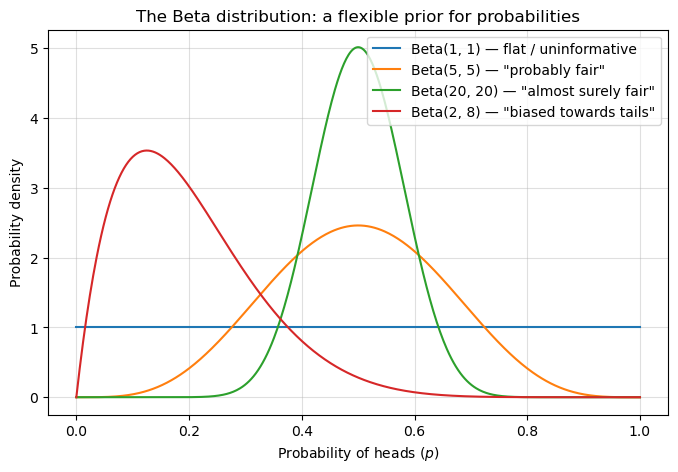

In [2]:
p = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 5))
for a, b, label in [(1, 1, 'Beta(1, 1) — flat / uninformative'),
                    (5, 5, 'Beta(5, 5) — "probably fair"'),
                    (20, 20, 'Beta(20, 20) — "almost surely fair"'),
                    (2, 8, 'Beta(2, 8) — "biased towards tails"')]:
    plt.plot(p, stats.beta.pdf(p, a, b), label=label)

plt.xlabel('Probability of heads ($p$)')
plt.ylabel('Probability density')
plt.title('The Beta distribution: a flexible prior for probabilities')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

### 3.2 Conjugate priors: the posterior for free

Here is the beautiful part. If the prior is a Beta distribution and the likelihood is binomial, the posterior is **also a Beta distribution** — with parameters you can write down instantly:

$$
\mathrm{Beta}(\alpha, \beta) \;+\; \underbrace{k \text{ heads in } n \text{ flips}}_{\text{data}} \;\;\longrightarrow\;\; \mathrm{Beta}(\alpha + k,\; \beta + n - k)
$$

Why does this work? Bayes' theorem says posterior $\propto$ likelihood $\times$ prior. Multiply the two forms and the exponents simply add:

$$
\underbrace{p^{k}(1-p)^{n-k}}_{\text{likelihood}} \times \underbrace{p^{\alpha-1}(1-p)^{\beta-1}}_{\text{prior}} = p^{(\alpha+k)-1}(1-p)^{(\beta+n-k)-1}
$$

The product has the Beta form again — it *cannot* leave the family. Because the prior "speaks the same language" as the likelihood, updating just means adding the observed heads and tails to the prior's pseudo-counts. No integration, no simulation — the dreaded evidence term $P(D)$ cancels out automatically. When the prior and posterior belong to the same family, we say the prior is **conjugate** to the likelihood. A few classic conjugate pairs:

| Likelihood | Conjugate prior | Posterior |
|---|---|---|
| Binomial (counts of successes) | Beta | Beta |
| Normal with known variance (continuous data) | Normal | Normal |
| Poisson (event rates) | Gamma | Gamma |

**If your problem fits a conjugate pair, the entire Bayesian analysis is one line of algebra.** Always check this before reaching for heavier machinery. Let's apply it to our coin:

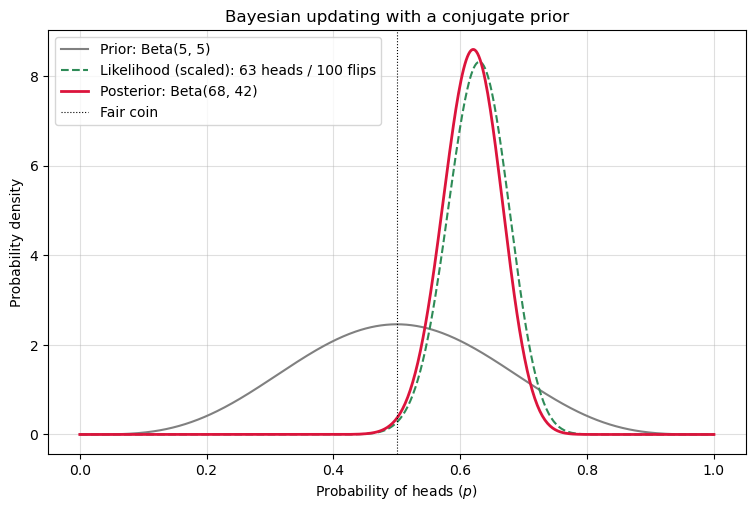

Posterior mean of p:      0.6182
95% credible interval:    [0.5260, 0.7063]


In [3]:
# Data
n = 100   # number of coin flips
k = 63    # number of heads

# Prior: Beta(5, 5) — "probably fair, but not certain"
alpha_prior, beta_prior = 5, 5

# Posterior: conjugacy gives it to us analytically, in one line!
alpha_post = alpha_prior + k          # add the heads
beta_post  = beta_prior + (n - k)     # add the tails

# Prior, (scaled) likelihood, and posterior, for plotting
prior_pdf      = stats.beta.pdf(p, alpha_prior, beta_prior)
likelihood     = stats.binom.pmf(k, n, p)
posterior_pdf  = stats.beta.pdf(p, alpha_post, beta_post)

plt.figure(figsize=(9, 5.5))
plt.plot(p, prior_pdf, color='gray', label=f'Prior: Beta({alpha_prior}, {beta_prior})')
plt.plot(p, likelihood / (likelihood.sum() * (p[1] - p[0])), color='seagreen', linestyle='--',
         label=f'Likelihood (scaled): {k} heads / {n} flips')
plt.plot(p, posterior_pdf, color='crimson', linewidth=2,
         label=f'Posterior: Beta({alpha_post}, {beta_post})')
plt.axvline(0.5, color='k', linewidth=0.8, linestyle=':', label='Fair coin')
plt.xlabel('Probability of heads ($p$)')
plt.ylabel('Probability density')
plt.title('Bayesian updating with a conjugate prior')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

# Because the posterior is a known distribution, summaries are exact:
post_mean = alpha_post / (alpha_post + beta_post)
ci_low, ci_high = stats.beta.ppf([0.025, 0.975], alpha_post, beta_post)
print(f"Posterior mean of p:      {post_mean:.4f}")
print(f"95% credible interval:    [{ci_low:.4f}, {ci_high:.4f}]")

---

**_Aside_**: *Increase $n$ and $k$ by an order of magnitude (1000 flips, 630 heads) and re-run the cell. How do the posterior mean and the credible interval change, and why? What happens if you make the prior much stronger, e.g. $\mathrm{Beta}(200, 200)$?*

---

### Takeaway

The posterior balances our prior assumption against the observed data: with few observations it stays close to the prior; as evidence accumulates it concentrates around the data. The mean of the posterior is our best estimate of the coin's bias, and the **95% credible interval** has exactly the interpretation everyone *wants* confidence intervals to have: *"given the data, there is a 95% probability that $p$ lies in this range."*

And because our prior was **conjugate**, we did all of this analytically — no sampling required. Hold that thought.

---

## 4. A Real Problem: Glacier Melt vs Air Temperature

In climate science, priors let us build **physically-grounded** statistical models: we can assign priors to model parameters that reflect known physical behaviour or limits. Frequentist models lack this flexibility — they listen only to the data, and when the data are scarce or noisy they may overfit or produce physically implausible results.

Let's test that claim. We will first fit a classical (frequentist) regression to the Spitsbergen melt data, inspect its weaknesses, and then design a Bayesian model that fixes them.

### 4.1 Import and plot the data

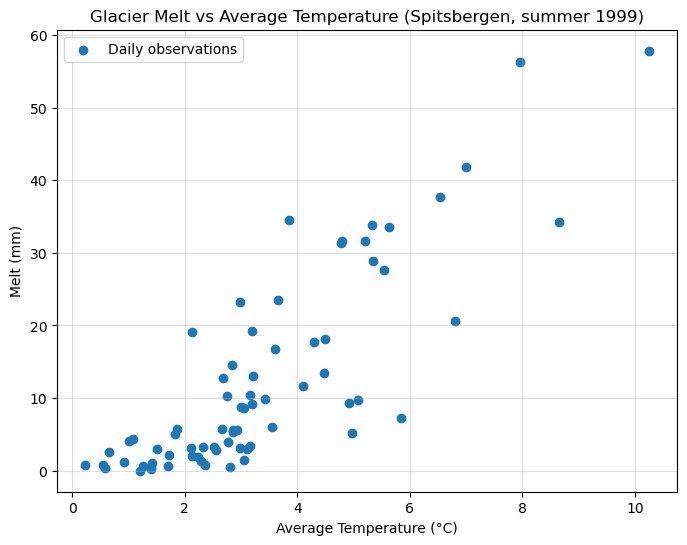

In [4]:
# Read the data (relative to this notebook's location)
data = pd.read_csv('../data/Glac_Melt.csv')

av_temp = data['AvTemp']
melt = data['Melt']

plt.figure(figsize=(8, 6))
plt.scatter(av_temp, melt, marker='o', label='Daily observations')
plt.title('Glacier Melt vs Average Temperature (Spitsbergen, summer 1999)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Melt (mm)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

There is a clear relationship between the two variables, and it is slightly nonlinear — glaciers typically have a threshold temperature above which melt accelerates due to feedbacks (e.g. the albedo feedback). A simple quadratic model captures this:

$$
\mathrm{Melt} = \beta_0 + \beta_1 \cdot \mathrm{AvTemp} + \beta_2 \cdot \mathrm{AvTemp}^2 + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$

where $\beta_0$ is the intercept, $\beta_1$ and $\beta_2$ the linear and quadratic coefficients, and $\epsilon$ the noise term.

### 4.2 The frequentist fit

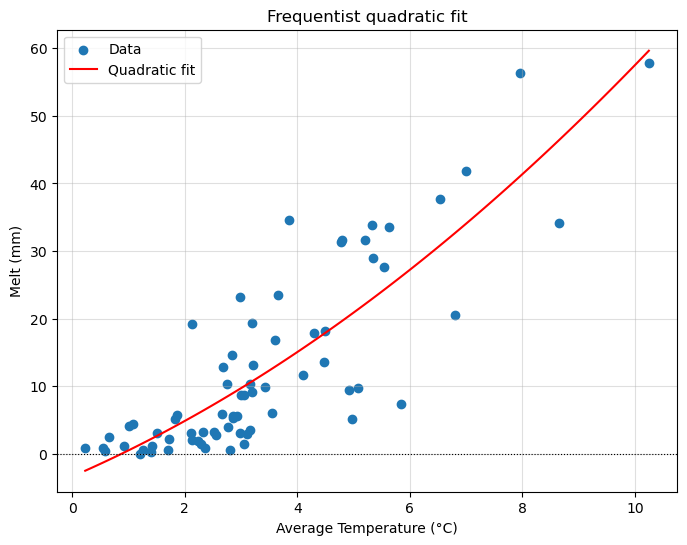

β₂ (quadratic term): 0.2478
β₁ (linear term):    3.6130
β₀ (intercept):      -3.3847   <-- look closely at this one!
R²:                  0.7076


In [5]:
# Fit a quadratic model (degree 2). np.polyfit returns best-fit coefficients
# (highest degree first) but no uncertainties.
b2, b1, b0 = np.polyfit(av_temp, melt, 2)

# Smooth curve for plotting
curve_x = np.linspace(av_temp.min(), av_temp.max(), 100)
curve_y = np.polyval([b2, b1, b0], curve_x)

plt.figure(figsize=(8, 6))
plt.scatter(av_temp, melt, marker='o', label='Data')
plt.plot(curve_x, curve_y, color='red', label='Quadratic fit')
plt.axhline(0, color='k', linewidth=0.8, linestyle=':')
plt.title('Frequentist quadratic fit')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Melt (mm)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

# Goodness of fit: R^2
predicted = np.polyval([b2, b1, b0], av_temp)
residuals = melt - predicted
r_squared = 1 - np.sum(residuals**2) / np.sum((melt - melt.mean())**2)

print(f"β₂ (quadratic term): {b2:.4f}")
print(f"β₁ (linear term):    {b1:.4f}")
print(f"β₀ (intercept):      {b0:.4f}   <-- look closely at this one!")
print(f"R²:                  {r_squared:.4f}")

### 4.3 The red flag

The model explains a large portion of the variance ($R^2 \approx 0.7$) and the residuals look reasonable. But there is one big problem:

> **The intercept is negative — the model predicts *negative melting* at 0 °C. That is physically impossible.**

The frequentist model fits the observations well, yet it violates the physics — a direct consequence of a small, noisy dataset. We could cherry-pick outliers, or spend time and money on more measurements... or **we could go Bayesian and put the physics directly into the model** through a prior that says the intercept cannot be negative. How cool is that?

---

## 5. When Conjugacy Fails: Markov Chain Monte Carlo

With the coin, a conjugate prior gave us the posterior in one line. Can we do that here? Unfortunately, no:

- our model is a **quadratic regression with unknown noise** $\sigma$ (4 parameters, not 1),
- and our physical constraint requires a **truncated prior** on the intercept ($\beta_0 \geq 0$).

That combination has no conjugate solution — there is no neat formula for the posterior. This is the norm, not the exception: most real-world Bayesian models are not conjugate. What we *can* always do is compute the **numerator** of Bayes' theorem (likelihood × prior) for any candidate parameter set. The intractable part is only the evidence $P(D)$, the normalising integral.

**MCMC** algorithms exploit exactly this: they generate samples whose long-run distribution is the posterior, *using only the un-normalised numerator*. The algorithm wanders through parameter space, spending time in each region in proportion to its posterior probability. The recipe (the **Metropolis–Hastings** algorithm):

1. **Initialise**: start with a guess for the parameters $(\beta_0, \beta_1, \beta_2, \sigma)$.
2. **Propose**: perturb the current parameters with a small amount of Gaussian noise.
3. **Accept or reject**: compute the acceptance ratio
   $$\text{Acceptance Ratio} = \min\!\left(1, \frac{P(\theta_{\text{proposed}} \mid y)}{P(\theta_{\text{current}} \mid y)}\right)$$
   If the proposal explains the data better (ratio > 1), always accept it. If it is worse, accept it *with probability equal to the ratio* — this occasional acceptance of worse states is what lets the chain escape local optima and explore the full posterior.
4. **Repeat** thousands of times, building a *chain* of sampled states.

Here is the algorithm running on **exactly the model you are about to build** — the left panel walks through parameter space (green = accepted proposal, red = rejected), and the right panel shows the regression curve corresponding to the current state:

![MCMC on the glacier model](assets/mcmc_glacier.gif)

*Note how the chain starts from a terrible guess, quickly finds the high-probability region, and then keeps exploring it — and how the cloud of samples piles up against the physical limit $\beta_0 \geq 0$ without ever crossing it. The bottom panel tracks the log-posterior of the current state: it looks just like the loss curves from yesterday's neural-network practicals, but with one crucial difference — after the initial climb (the *burn-in*), the chain does not settle at the peak. It keeps wandering around the high-probability region *on purpose*, because our goal is not to find the single best parameter set but to map out the whole posterior distribution.*

---

## 6. Building the Bayesian Model

We now write the four ingredients as Python functions: the likelihood, the prior, the proposal, and the sampler itself. First, the variables:

In [6]:
# Independent (x) and dependent (y) variables as NumPy arrays
x = data['AvTemp'].values
y = data['Melt'].values

### 6.1 The likelihood

The likelihood is the probability of observing our melt data $y$ given a candidate parameter set $\theta = (\beta_2, \beta_1, \beta_0, \sigma)$. Since the model assumes Gaussian noise, we (1) compute the model prediction, (2) take the residuals, and (3) look up their probability density under $\mathcal{N}(0, \sigma)$.

In practice we always work with the **log**-likelihood — products of many small probabilities underflow to zero, whereas sums of logs are numerically stable:

$$
\log L(\theta \mid y) = -\frac{1}{2} \sum_{i=1}^{n} \left[ \left( \frac{y_i - \hat{y}_i}{\sigma} \right)^2 + \log(2\pi\sigma^2) \right]
$$

where $\hat{y}_i = \beta_2 x_i^2 + \beta_1 x_i + \beta_0$ is the model prediction for data point $i$.

In [7]:
def log_likelihood(params):
    b2, b1, b0, sigma = params
    pred = b2 * x**2 + b1 * x + b0            # model prediction
    residuals = y - pred                       # misfit to observations
    return -0.5 * np.sum((residuals / sigma)**2 + np.log(2 * np.pi * sigma**2))

### 6.2 The priors — where the physics goes in

We specify a prior for each parameter:

- $\beta_2, \beta_1 \sim \mathcal{N}(0, 10)$ — weakly informative; we have no strong opinion about the curvature or slope.
- $\beta_0 \sim \mathcal{U}(0, 5)$ — **here is our physical knowledge**: no negative melting in nature! The hard lower bound at 0 encodes the physical law.
- $\sigma \sim \mathcal{U}(0.1, 30)$ — the noise level must be positive; we allow a generous range.

The function below returns the **log prior density** of a candidate parameter set. If a candidate falls outside the hard bounds, it returns $-\infty$ — i.e. zero prior probability, so the sampler will *never* accept it. This is how the constraint $\beta_0 \geq 0$ is enforced.

The log posterior (up to the unknown normalising constant — all MCMC needs) is then simply **log-likelihood + log-prior**.

In [8]:
def log_prior(params):
    b2, b1, b0, sigma = params
    # Hard physical bounds: zero probability outside them
    if not (0 <= b0 <= 5) or not (0.1 <= sigma <= 30):
        return -np.inf
    # Weakly informative normal priors on the polynomial coefficients
    log_p_b2 = -0.5 * (b2 / 10)**2
    log_p_b1 = -0.5 * (b1 / 10)**2
    return log_p_b2 + log_p_b1     # (constant terms omitted — they cancel in the ratio)

def log_posterior(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf             # don't waste time computing the likelihood
    return lp + log_likelihood(params)

### 6.3 The proposal

The proposal function suggests a new candidate by adding Gaussian noise to the current parameters:

$$\theta_{\text{proposed}} = \theta_{\text{current}} + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \text{step\_sizes})$$

The `step_sizes` control how far each proposal can "jump". This is the key tuning knob of Metropolis–Hastings: steps too large → almost everything is rejected; steps too small → the chain crawls and gets stuck. A rule of thumb is to aim for an acceptance rate of roughly 20–40%. (We have tuned the values below for you — but see the exercise at the end of Section 7.)

In [9]:
step_sizes = np.array([0.08, 0.3, 0.5, 0.4])   # tuned for (b2, b1, b0, sigma)

def proposal(current_params):
    return current_params + rng.normal(0, step_sizes)

# Note: if a proposal lands outside the prior bounds, log_prior returns -inf
# and the sampler below automatically rejects it. The physics polices itself.

### 6.4 The Metropolis–Hastings sampler

Now we knit it all together. Each iteration proposes a candidate, evaluates its log-posterior, and accepts or rejects it. Because we work in log space, the acceptance test

$$u < \frac{P(\theta_{\text{prop}} \mid y)}{P(\theta_{\text{cur}} \mid y)} \quad\Longleftrightarrow\quad \log u < \log P(\theta_{\text{prop}} \mid y) - \log P(\theta_{\text{cur}} \mid y), \qquad u \sim \mathcal{U}(0,1)$$

becomes a simple subtraction. Two housekeeping details:

- **Burn-in**: the first samples are biased by the (arbitrary) starting point, so we discard them.
- **Thinning**: adjacent samples are correlated (each state depends on the previous one — that's the *Markov* in MCMC), so we keep only every `thin`-th sample.

In [10]:
def run_mcmc(initial_params, iterations=100_000, burnin=5_000, thin=10):
    samples = []
    current = np.array(initial_params, dtype=float)
    current_logpost = log_posterior(current)
    n_accepted = 0

    for i in range(iterations):
        proposed = proposal(current)
        proposed_logpost = log_posterior(proposed)

        # Metropolis-Hastings acceptance test (in log space)
        if np.log(rng.random()) < proposed_logpost - current_logpost:
            current, current_logpost = proposed, proposed_logpost
            n_accepted += 1

        if i >= burnin and i % thin == 0:
            samples.append(current)

    print(f"Acceptance rate: {n_accepted / iterations:.1%}")
    return np.array(samples)

### 6.5 Run it!

We start the chain from a deliberately mediocre guess (as in the animation above) and let it run for 100,000 iterations — for a 4-parameter model this takes a few seconds. For more complex models you would run multiple chains for millions of iterations and check convergence with formal diagnostics (e.g. the Gelman–Rubin statistic); today a visual check will do.

In [11]:
samples = run_mcmc(initial_params=[0.0, 1.0, 2.5, 5.0])
print(f"Number of posterior samples kept: {len(samples)}")

Acceptance rate: 32.2%
Number of posterior samples kept: 9500


---

## 7. Diagnostics: Did the Chain Mix Well?

Before trusting any results, we look at the **trace plots** — the value of each parameter along the chain. A healthy, well-mixed chain looks like a "hairy caterpillar": rapid fluctuation around a stable level, with no drifts or long flat stretches.

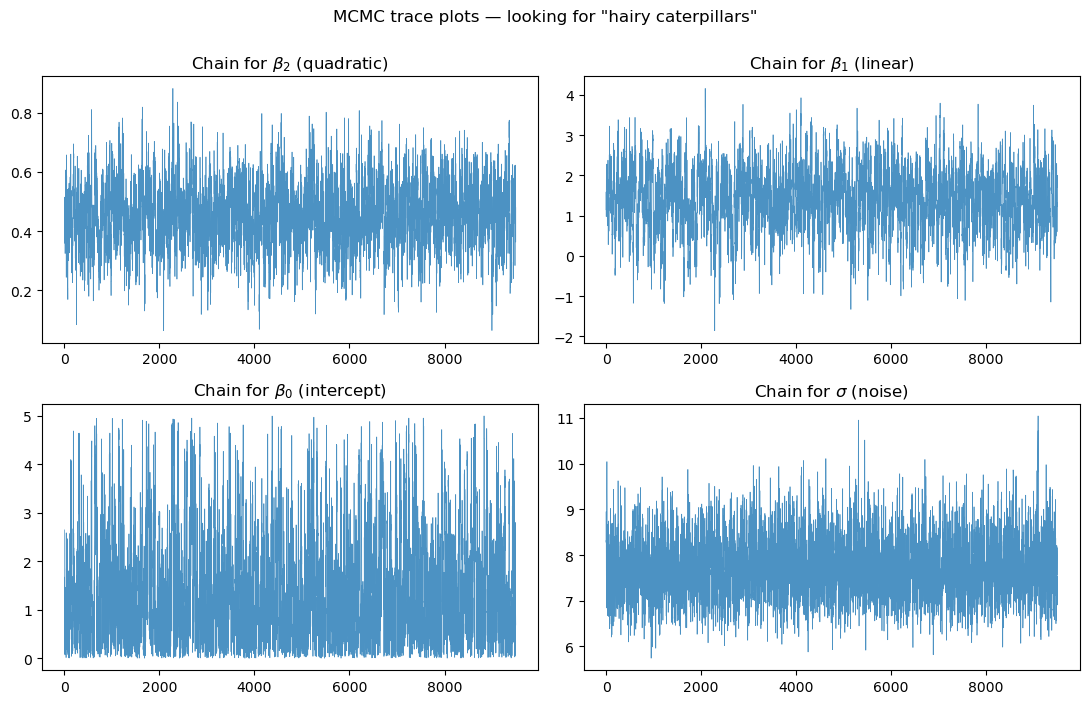

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
labels = [r'$\beta_2$ (quadratic)', r'$\beta_1$ (linear)', r'$\beta_0$ (intercept)', r'$\sigma$ (noise)']

for i, ax in enumerate(axes.flatten()):
    ax.plot(samples[:, i], linewidth=0.5, alpha=0.8)
    ax.set_title(f'Chain for {labels[i]}')

fig.suptitle('MCMC trace plots — looking for "hairy caterpillars"', y=1.0)
plt.tight_layout()
plt.show()

Now the payoff: the **posterior distributions**. We overlay the frequentist point estimates (red dashed lines) for comparison.

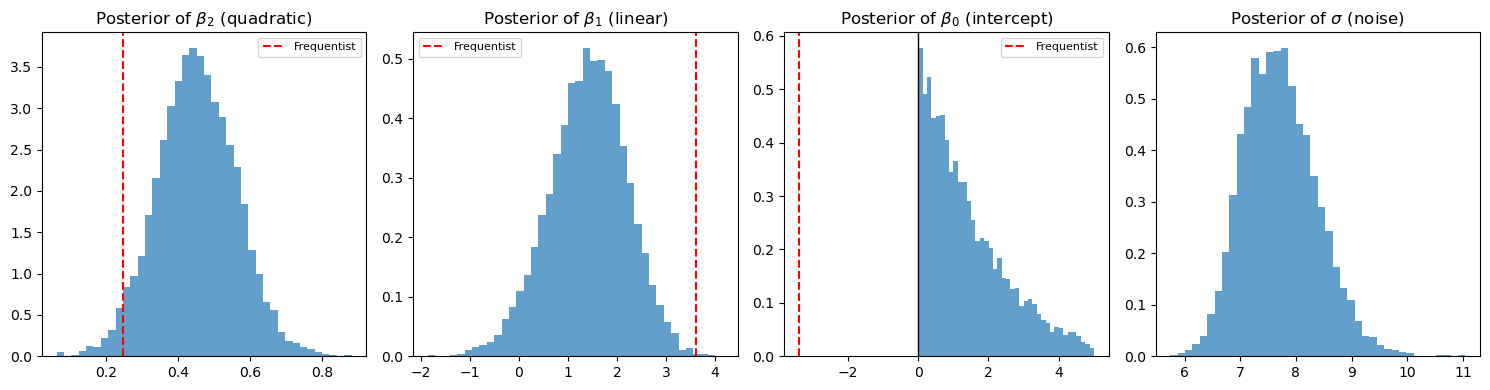

parameter     post. mean       95% credible interval
beta_2             0.452              [0.238, 0.666]
beta_1             1.409             [-0.219, 2.882]
beta_0             1.398              [0.044, 4.224]
sigma              7.717              [6.570, 9.094]


In [13]:
frequentist = [b2, b1, b0]   # from Section 4.2

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.hist(samples[:, i], bins=40, density=True, alpha=0.7)
    ax.set_title(f'Posterior of {labels[i]}')
    if i < 3:
        ax.axvline(frequentist[i], color='red', linestyle='--', label='Frequentist')
        ax.legend(fontsize=8)
    if i == 2:
        ax.axvline(0, color='k', linewidth=1)

plt.tight_layout()
plt.show()

# Posterior summaries
print(f"{'parameter':<12}{'post. mean':>12}{'95% credible interval':>28}")
for i, name in enumerate(['beta_2', 'beta_1', 'beta_0', 'sigma']):
    lo, hi = np.percentile(samples[:, i], [2.5, 97.5])
    print(f"{name:<12}{samples[:, i].mean():>12.3f}{f'[{lo:.3f}, {hi:.3f}]':>28}")

Look at the intercept $\beta_0$: the frequentist estimate sits at a *physically impossible* negative value, while the Bayesian posterior respects the limit — its entire mass lies above zero, piling up near the boundary exactly as we saw in the animation. Instead of a single impossible number, we now have a full distribution of *plausible, physical* values.

---

**_Aside_**: *Re-run the sampler with much smaller step sizes (multiply `step_sizes` by 0.1) and much larger ones (multiply by 10). Watch the acceptance rate and the trace plots: when do the chains look "hairy" (good mixing) and when do they look "sticky" (poor mixing)?*

---

**A cautionary note**: Metropolis–Hastings is the simplest and most versatile MCMC sampler, and it works perfectly well for low-dimensional models like ours. For high-dimensional problems with complex, multimodal posteriors, you would use dedicated libraries with smarter samplers — e.g. [PyMC](https://www.pymc.io/), [emcee](https://emcee.readthedocs.io/), or [Stan](https://mc-stan.org/). The concepts you learned today transfer directly.

---

## 8. The Bayesian Model Fit

Finally, let's fit the data with our Bayesian model. Every posterior sample defines a candidate curve; the spread of those curves *is* our uncertainty. We summarise it with the posterior-mean curve and a **95% credibility band** — the Bayesian counterpart of a confidence band, with the more natural interpretation.

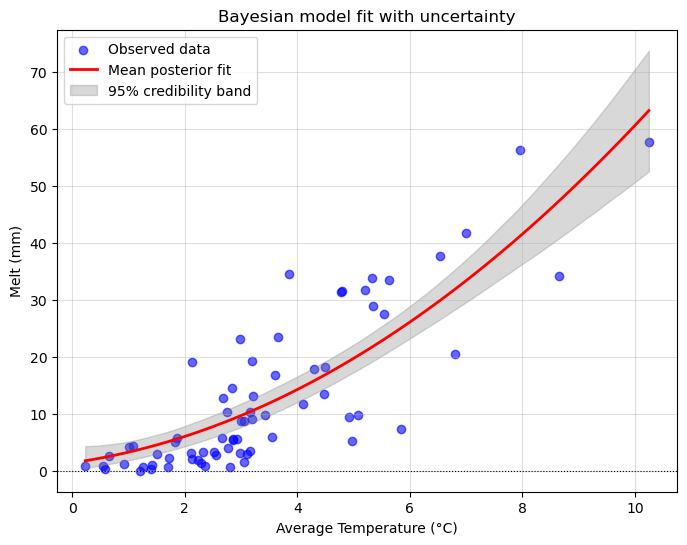

In [14]:
# One predicted curve per posterior sample
x_range = np.linspace(x.min(), x.max(), 100)
predictions = (samples[:, 0:1] * x_range**2      # b2 * x^2
               + samples[:, 1:2] * x_range       # b1 * x
               + samples[:, 2:3])                # b0

mean_prediction = predictions.mean(axis=0)
lower, upper = np.percentile(predictions, [2.5, 97.5], axis=0)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', alpha=0.6, label='Observed data')
plt.plot(x_range, mean_prediction, color='red', linewidth=2, label='Mean posterior fit')
plt.fill_between(x_range, lower, upper, color='gray', alpha=0.3, label='95% credibility band')
plt.axhline(0, color='k', linewidth=0.8, linestyle=':')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Melt (mm)')
plt.title('Bayesian model fit with uncertainty')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

Unlike the frequentist fit, the Bayesian model never predicts negative melting — even at the lower edge of the credibility band. The physics we encoded in the prior propagates all the way through to the predictions.

(Bear in mind this is still a simple model — a quadratic may not be the ideal functional form for melt, and a serious analysis would compare alternative nonlinear models.)

### Beyond model error: measurement errors

One loose end before we wrap up. The $\sigma$ in our model captures the **model error** — scatter in the relationship between temperature and melt that our quadratic doesn't explain. But the melt *measurements themselves* also carry error: no instrument is perfect. Suppose the melt sensor has a measurement error of about 5% of the reading, $\tau_i = 0.05 \cdot \hat{y}_i$.

Because the model error and the measurement error are independent, their **variances simply add**:

$$
\mathrm{Var}(y_{obs}) = \sigma^2 + \tau^2
$$

Folding this into the Bayesian model takes one change to the likelihood — replace $\sigma^2$ with the total variance:

In [ ]:
# Concept only — read this, no need to run it today.
# The ONLY change from log_likelihood() in Section 6.1 is the total_variance line.

def log_likelihood_with_measurement_error(params):
    b2, b1, b0, sigma = params
    pred = b2 * x**2 + b1 * x + b0

    measurement_error = 0.05 * pred                     # tau: assumed 5% sensor error
    total_variance = sigma**2 + measurement_error**2    # variances add!

    residuals = y - pred
    return -0.5 * np.sum(residuals**2 / total_variance + np.log(2 * np.pi * total_variance))

Here we had to *assume* the 5% — `Glac_Melt.csv` ships with no uncertainty information, which is common for legacy field data. But many modern datasets publish their measurement uncertainties alongside the values. **The dataset in your workgroup session this morning is one of them — and you will use exactly this trick there.**

---

## 9. What Have We Learned Today?

**Bayesian analysis** updates prior beliefs with data to produce posterior distributions. It shines for small, noisy datasets — the Earth-science norm — and lets us encode physical limits directly into statistical models, yielding realistic results *with* honest uncertainties.

**Conjugate priors** are the special cases where the posterior has a closed form (Beta–Binomial, Normal–Normal, Gamma–Poisson). When your problem fits one, the full Bayesian answer costs one line of algebra — always check first.

**MCMC** handles everything else. The Metropolis–Hastings sampler explores parameter space using only the *un-normalised* posterior (likelihood × prior), spending time in each region in proportion to its probability. Tuning (step sizes), burn-in, thinning, and mixing diagnostics are part of the craft.

In the workgroup session next, you will apply this machinery to a new dataset — and in your own research, whenever you face sparse, noisy observations and real physical constraints, you now know what to reach for.

---

### Suggested references

- Kruschke, J.K. (2010). *Bayesian data analysis.* WIREs Cognitive Science, 1(5), 658–676.
- Martin, O.A., Kumar, R. & Lao, J. (2021). *Bayesian Modeling and Computation in Python.* Chapman and Hall/CRC.
- Min, S.-K., Simonis, D. & Hense, A. (2007). *Probabilistic climate change predictions applying Bayesian model averaging.* Phil. Trans. R. Soc. A, 365, 2103–2116.

### Online resources

- A great [blog-post tutorial](https://blog.stata.com/2016/11/15/introduction-to-bayesian-statistics-part-2-mcmc-and-the-metropolis-hastings-algorithm/) on MCMC and Metropolis–Hastings.
- An [introduction to Bayesian statistics in Python](https://statsthinking21.github.io/statsthinking21-python/10-BayesianStatistics.html).
- For the paleo-geeks: [MCMC fitting of Milankovitch cycles to ice-core data](https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html).

---

*Instructor: Francesco Muschitiello (fm476), June 2026.*

**Generative AI Use Statement:** Parts of this tutorial's materials were created with the support of Claude and Gemini.